# Week 6 - Baseline Triage Model
Vishwesh Pattanaik | CariSurg MedTech Pathways 2026

Goal: train a defensible baseline that beats a coin flip, and be honest about where it fails.
Target = `esi` (1 = most urgent, 5 = least). **Random seed = 42** (also in the README).

### 1. Load data and build features

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, f1_score)

df = pd.read_csv("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")
cc = [c for c in df.columns if c.startswith("cc_")]

y = df["esi"].astype(int)

# numeric features (vitals + age)
num = ["age","triage_vital_hr","triage_vital_sbp","triage_vital_dbp","triage_vital_rr",
       "triage_vital_o2","triage_vital_temp","triage_glucose","triage_vital_o2_device"]

# NOTE: 'disposition' is dropped on purpose - it is the OUTCOME (admitted/discharged),
# known only after triage, so using it would leak the answer.
cats = pd.get_dummies(df[["gender","arrivalmode"]], drop_first=True)

X = pd.concat([df[num], df[cc], cats], axis=1)
print("feature matrix:", X.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
feature matrix: (55121, 216)


### 2. Train / test split (80/20, stratified on ESI)

In [ ]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# scale the numeric columns (logistic regression needs this; the cc flags are already 0/1)
scaler = StandardScaler().fit(Xtr[num])
Xtr, Xte = Xtr.copy(), Xte.copy()
Xtr[num] = scaler.transform(Xtr[num])
Xte[num] = scaler.transform(Xte[num])
print("train:", Xtr.shape[0], " test:", Xte.shape[0])

train: 44096  test: 11025


### 3. Train the logistic regression baseline

In [ ]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(Xtr, ytr)
pred = lr.predict(Xte)
print("done")

done


### 4. Evaluate

In [ ]:
print("Accuracy :", round(accuracy_score(yte, pred), 3))
print("Macro F1 :", round(f1_score(yte, pred, average="macro"), 3))
print("Weighted F1:", round(f1_score(yte, pred, average="weighted"), 3))
print()
print(classification_report(yte, pred, digits=3))

Accuracy : 0.685
Macro F1 : 0.518
Weighted F1: 0.679

              precision    recall  f1-score   support

           1      0.800     0.250     0.381        16
           2      0.733     0.618     0.671      3585
           3      0.676     0.777     0.723      5402
           4      0.640     0.622     0.631      1779
           5      0.483     0.115     0.186       243

    accuracy                          0.685     11025
   macro avg      0.666     0.476     0.518     11025
weighted avg      0.685     0.685     0.679     11025



Accuracy is 0.68, but that hides the problem. Look at the **per-class recall**: the model catches most ESI 2 and 3 patients but only a quarter of ESI 1, the sickest. Macro F1 (0.52) is much lower than weighted F1 (0.68) because macro treats every class equally and so is dragged down by the poor performance on the rare, dangerous classes.

### 5. Confusion matrix

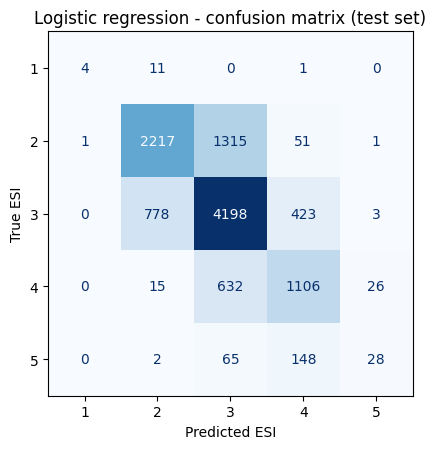

In [ ]:
fig, ax = plt.subplots(figsize=(5.2,4.6))
ConfusionMatrixDisplay.from_predictions(yte, pred, labels=[1,2,3,4,5],
                                        cmap="Blues", ax=ax, colorbar=False, values_format="d")
ax.set_title("Logistic regression - confusion matrix (test set)")
ax.set_xlabel("Predicted ESI"); ax.set_ylabel("True ESI")
plt.tight_layout(); plt.show()

The top row is the worry. Of the ESI 1 patients in the test set, most are predicted as ESI 2 or lower. In a real ED that is an under-triaged critical patient sent to wait.

### 6. Compare against a random-guess baseline

In [ ]:
dummy = DummyClassifier(strategy="stratified", random_state=42).fit(Xtr, ytr)
dpred = dummy.predict(Xte)
print("Random guess accuracy :", round(accuracy_score(yte, dpred), 3))
print("Logistic regression   :", round(accuracy_score(yte, pred), 3))
# the baseline clearly beats a coin flip (Dr De Freitas' bar)

Random guess accuracy : 0.375
Logistic regression   : 0.685


### 7. Early read
- The baseline beats a stratified random guess (0.68 vs 0.38 accuracy), so the signal is real.
- The failure mode that matters: **recall on ESI 1 is only 0.25**. The model misses three out of four of the most urgent patients. For triage, missing a Level 1 is far worse than mislabelling a Level 4, which is why recall on the urgent classes, not overall accuracy, will be the primary metric.
- Next (final): add the decision tree baseline, and test class weighting to lift ESI-1 recall.